In [1]:
import importlib, sys
sys.path.insert(0, 'code')
import variants
importlib.reload(variants)
print('three_channel_pinn' in dir(variants))

True


In [2]:
import os, sys, time
import numpy as np
import torch
import matplotlib.pyplot as plt
sys.path.insert(0, 'code')
from shared import load_condition, glauber_constants, mse
from variants import (
    three_separate_pinns,
    inverse_pinn,
    pinn_analytical,
    three_channel_pinn,
    per_run_pinn,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

plt.rcParams.update({
    "axes.titlesize":  14,
    "axes.labelsize":  13,
    "legend.fontsize": 11,
})

device: cpu


In [3]:
data = load_condition(return_per_run=True)
t_grid = data['t_grid']
m_bar = data['m_bar']
eps_bar = data['eps_bar']
eps2_bar = data['eps2_bar']
a0_true, a1_true, a2_true = glauber_constants(
    data['beta_true'], data['h_true'], data['J_true']
)

print(f'Condition: β={data["beta_true"]:+.3f}  h={data["h_true"]:+.3f}  J={data["J_true"]:+.3f}')
print(f'Analytical (a₀, a₁, a₂) = ({a0_true:+.4f}, {a1_true:+.4f}, {a2_true:+.4f})')

Condition: β=+0.900  h=+0.058  J=+1.167
Analytical (a₀, a₁, a₂) = (+0.0547, +0.9703, -0.0487)


In [6]:
results = {}

for fn, key in [
    (three_separate_pinns, 'three_separate'),
    (inverse_pinn, 'inverse'),
    (pinn_analytical, 'analytical'),
    (three_channel_pinn, 'three_channel'),
    (per_run_pinn, 'per_run'),
]:
    print(f'\n {fn.__name__} ')
    r = fn(data, device=device)
    r['mse_m']    = mse(r['m_hat'],    m_bar)
    r['mse_eps']  = mse(r['eps_hat'],  eps_bar)
    r['mse_eps2'] = mse(r['eps2_hat'], eps2_bar)
    r['da0'] = abs(r['a0'] - a0_true)
    r['da1'] = abs(r['a1'] - a1_true)
    r['da2'] = abs(r['a2'] - a2_true)
    r['da_mean'] = (r['da0'] + r['da1'] + r['da2']) / 3.0
    results[key] = r
    print(f'MSE m = {r["mse_m"]:.2e} MSE ε = {r["mse_eps"]:.2e} MSE ε₂ = {r["mse_eps2"]:.2e}')
    print(f'recovered (a₀, a₁, a₂) = ({r["a0"]:+.4f}, {r["a1"]:+.4f}, {r["a2"]:+.4f})')
    print(f'mean Δa = {r["da_mean"]:.3e} {r["n_params"]:,} params {r["time_sec"]:.1f} s')


 three_separate_pinns 


/Users/mekhachatryan/DS Capstone/code/shared.py:93: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  history.append(float(L))


MSE m = 4.51e-06 MSE ε = 3.74e-05 MSE ε₂ = 8.82e-07
recovered (a₀, a₁, a₂) = (+0.0989, +0.6086, +1.4744)
mean Δa = 6.430e-01 38,028 params 24.4 s

 inverse_pinn 
MSE m = 1.06e-06 MSE ε = 2.75e-05 MSE ε₂ = 3.65e-03
recovered (a₀, a₁, a₂) = (+0.0331, +0.9607, -0.0284)
mean Δa = 1.716e-02 12,676 params 12.1 s

 pinn_analytical 
MSE m = 2.56e-06 MSE ε = 2.67e-05 MSE ε₂ = 8.90e-05
recovered (a₀, a₁, a₂) = (+0.0841, +0.7183, +0.9344)
mean Δa = 4.215e-01 12,676 params 12.0 s

 three_channel_pinn 
MSE m = 6.16e-05 MSE ε = 9.78e-06 MSE ε₂ = 2.32e-06
recovered (a₀, a₁, a₂) = (+0.5824, -0.0700, +0.3985)
mean Δa = 6.717e-01 12,806 params 15.7 s

 per_run_pinn 
MSE m = 6.86e-05 MSE ε = 3.10e-05 MSE ε₂ = 1.20e-04
recovered (a₀, a₁, a₂) = (+0.0665, +0.8119, +0.5589)
mean Δa = 2.593e-01 12,676 params 12.6 s


In [ ]:
header = (f'{"variant":<42s}  {"MSE m":>9s}  {"MSE ε":>9s}  {"MSE ε₂":>9s}  '
          f'{"Δa mean":>11s}  {"params":>8s}  {"time (s)":>8s}')
for key in ['three_separate', 'inverse', 'analytical', 'three_channel', 'per_run']:
    r = results[key]
    print(f'{r["name"]:<42s}  '
          f'{r["mse_m"]:>9.2e}  {r["mse_eps"]:>9.2e}  {r["mse_eps2"]:>9.2e}  '
          f'{r["da_mean"]:>11.3e}  {r["n_params"]:>8,d}  {r["time_sec"]:>8.1f}')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
variant                                         MSE m      MSE ε     MSE ε₂    |Δa| mean    params  time (s)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Three separate PINNs                         4.51e-06   3.74e-05   8.82e-07    6.430e-01    38,028      25.2
Inverse PINN  (β, h, J learnable)            1.06e-06   2.75e-05   3.65e-03    1.716e-02    12,676      12.3
PINN-Analytical (chosen)                     2.56e-06   2.67e-05   8.90e-05    4.215e-01    12,676      12.5
3-channel PINN (fully supervised)            6.16e-05   9.78e-06   2.32e-06    6.717e-01    12,806      16.2
Per-run PINN  (single sub-run, R[idx]=0)     6.86e-05   3.10e-05   1.20e-04    2.593e-01    12,676      13.3
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


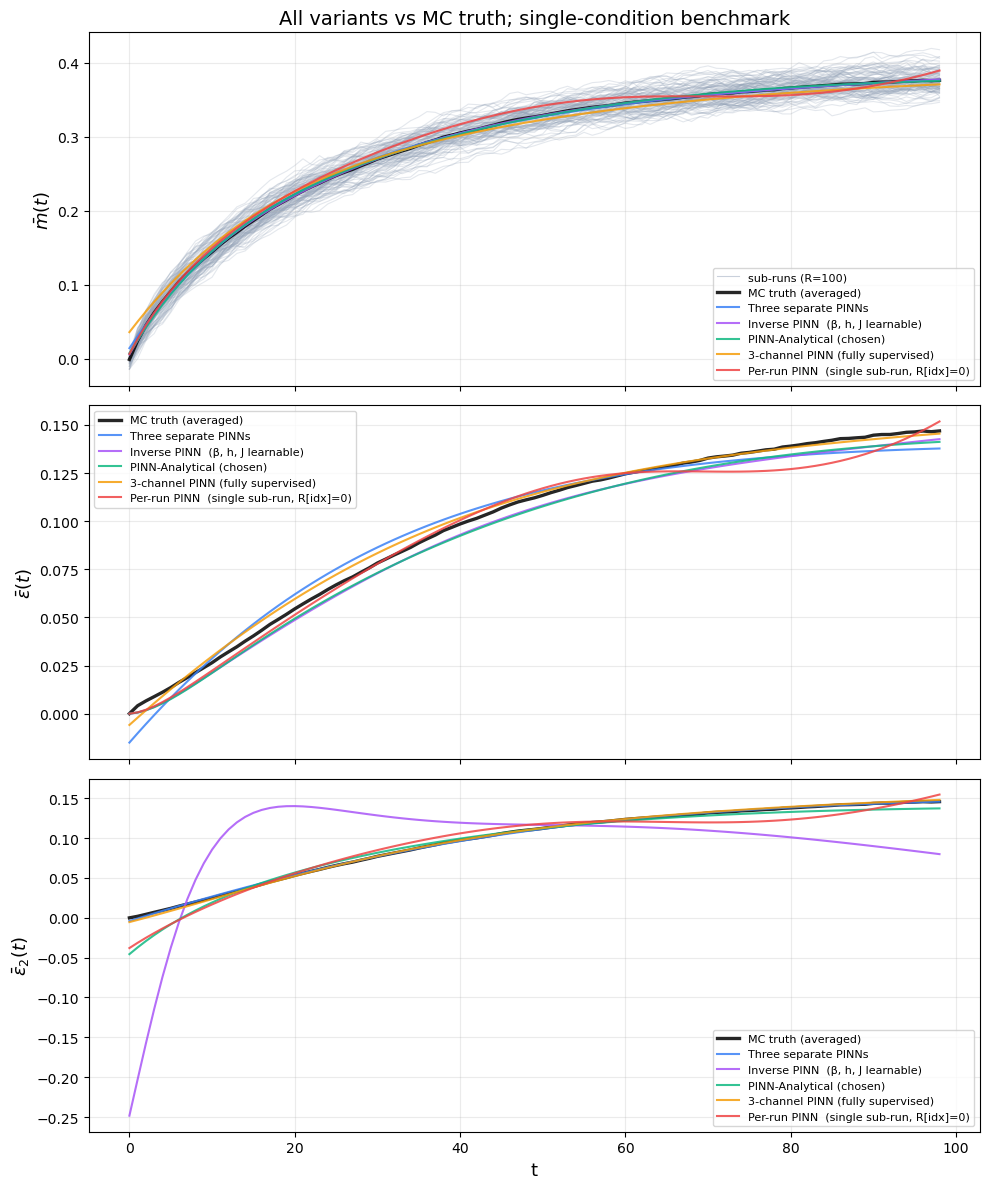

In [7]:
colors = {'three_separate': '#3b82f6', 'inverse': '#a855f7', 'analytical': '#10b981',
          'three_channel': '#f59e0b', 'per_run': '#ef4444'}

fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
for ax_idx, (ax, (truth, key_obs, lbl)) in enumerate(zip(axes, [
    (m_bar, 'm_hat', r'$\bar m(t)$'),
    (eps_bar, 'eps_hat', r'$\bar\varepsilon(t)$'),
    (eps2_bar, 'eps2_hat', r'$\bar\varepsilon_2(t)$'),
])):

    if ax_idx == 0 and 'm_per_run' in data:
        for run in data['m_per_run']:
            ax.plot(t_grid, run, color='#94a3b8', lw=0.8, alpha=0.25, zorder=0)
        ax.plot([], [], color='#94a3b8', lw=0.8, alpha=0.5,
                label=f'sub-runs (R={data["m_per_run"].shape[0]})')
    ax.plot(t_grid, truth, 'k-', lw=2.4, alpha=0.85, label='MC truth (averaged)')
    for key, r in results.items():
        ax.plot(t_grid, r[key_obs], color=colors[key], lw=1.5, alpha=0.85, label=r['name'])
    ax.set_ylabel(lbl)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8, loc='best')
axes[-1].set_xlabel('t')
axes[0].set_title('All variants vs MC truth; single-condition benchmark')
plt.tight_layout(); plt.show()

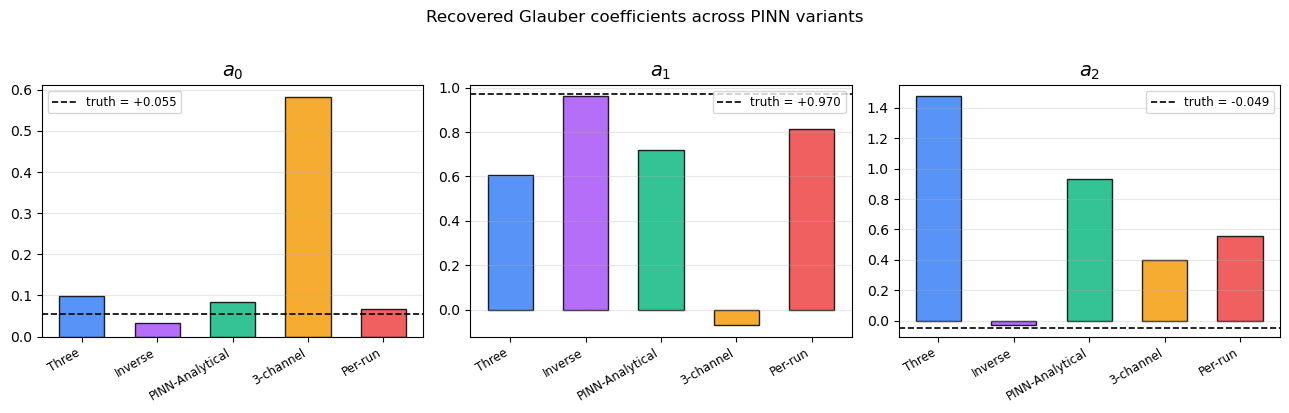

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (lbl, key_a, true_val) in zip(axes, [
    (r'$a_0$', 'a0', a0_true),
    (r'$a_1$', 'a1', a1_true),
    (r'$a_2$', 'a2', a2_true),
]):
    names  = [results[k]['name'].split(' ')[0] for k in results]
    values = [results[k][key_a] for k in results]
    bar_colors = [colors[k] for k in results]
    xs = np.arange(len(values))
    ax.bar(xs, values, 0.6, color=bar_colors, edgecolor='black', alpha=0.85)
    ax.axhline(true_val, color='k', ls='--', lw=1.2, label=f'truth = {true_val:+.3f}')
    ax.set_xticks(xs); ax.set_xticklabels(names, rotation=30, ha='right', fontsize=8.5)
    ax.set_title(lbl); ax.grid(True, axis='y', alpha=0.3)
    ax.legend(fontsize=8.5, loc='best')
plt.suptitle('Recovered Glauber coefficients across PINN variants', y=1.02)
plt.tight_layout(); plt.show()

In [ ]:
T_TRAIN_MAX = 50.0
mask_train = t_grid < T_TRAIN_MAX
mask_test = t_grid >= T_TRAIN_MAX
print(f'Training half: {mask_train.sum()} points (t < {T_TRAIN_MAX})')
print(f'Test half: {mask_test.sum()} points (t >= {T_TRAIN_MAX})')

results_x = {}

for fn, key in [
    (three_separate_pinns, 'three_separate'),
    (inverse_pinn, 'inverse'),
    (pinn_analytical, 'analytical'),
    (three_channel_pinn, 'three_channel'),
    (per_run_pinn, 'per_run'),
]:
    print(f'\n {fn.__name__}')
    r = fn(data, device=device, t_train_max=T_TRAIN_MAX)

    def split_mse(pred, truth, mask):
        return float(((pred - truth)[mask] ** 2).mean())

    r['mse_m_train'] = split_mse(r['m_hat'], m_bar, mask_train)
    r['mse_m_test'] = split_mse(r['m_hat'], m_bar, mask_test)
    r['mse_eps_test'] = split_mse(r['eps_hat'], eps_bar, mask_test)
    r['mse_eps2_test'] = split_mse(r['eps2_hat'], eps2_bar, mask_test)
    r['da_mean'] = (abs(r['a0'] - a0_true) +
                           abs(r['a1'] - a1_true) +
                           abs(r['a2'] - a2_true)) / 3.0
    results_x[key] = r
    ratio = r['mse_m_test'] / max(r['mse_m_train'], 1e-30)
    print(f'MSE m train={r["mse_m_train"]:.2e} test={r["mse_m_test"]:.2e}  ratio={ratio:.1f}×')
    print(f'MSE ε test={r["mse_eps_test"]:.2e} MSE ε₂ test={r["mse_eps2_test"]:.2e}')
    print(f'recovered (a₀, a₁, a₂) = ({r["a0"]:+.4f}, {r["a1"]:+.4f}, {r["a2"]:+.4f}) Δa = {r["da_mean"]:.3e}')

Training half: 50 points (t < 50.0)
Test half    : 49 points (t >= 50.0)

──── Extrapolating three_separate_pinns (train: t<50.0) ────
  MSE m  train=3.76e-06  test=1.35e-05  ratio=3.6×
  MSE ε  test=2.90e-04    MSE ε₂ test=6.08e-06
  recovered (a₀, a₁, a₂) = (+0.0759, +0.7367, +0.8890)    |Δa| = 3.975e-01

──── Extrapolating inverse_pinn (train: t<50.0) ────
  MSE m  train=1.62e-06  test=7.80e-06  ratio=4.8×
  MSE ε  test=1.41e-05    MSE ε₂ test=8.10e-04
  recovered (a₀, a₁, a₂) = (+0.0328, +0.9612, -0.0282)    |Δa| = 1.717e-02

──── Extrapolating pinn_analytical (train: t<50.0) ────
  MSE m  train=1.63e-06  test=9.49e-06  ratio=5.8×
  MSE ε  test=1.26e-05    MSE ε₂ test=2.59e-05
  recovered (a₀, a₁, a₂) = (+0.0819, +0.7040, +1.0365)    |Δa| = 4.595e-01

──── Extrapolating three_channel_pinn (train: t<50.0) ────
  MSE m  train=5.81e-05  test=1.38e-03  ratio=23.7×
  MSE ε  test=1.64e-04    MSE ε₂ test=5.31e-05
  recovered (a₀, a₁, a₂) = (+0.5387, -0.0672, +0.4404)    |Δa| = 6.702e-01



In [ ]:
header = (f'{"variant":<42s}  {"train MSE m":>12s}  {"test MSE m":>12s}  '
          f'{"test/train":>11s}  {"test MSE ε":>12s}  {"test MSE ε₂":>12s}  {"|Δa|":>9s}')
for key in ['three_separate', 'inverse', 'analytical', 'three_channel', 'per_run']:
    r = results_x[key]
    ratio = r['mse_m_test'] / max(r['mse_m_train'], 1e-30)
    print(f'{r["name"]:<42s}  '
          f'{r["mse_m_train"]:>12.2e}  {r["mse_m_test"]:>12.2e}  {ratio:>10.1f}×  '
          f'{r["mse_eps_test"]:>12.2e}  {r["mse_eps2_test"]:>12.2e}  {r["da_mean"]:>9.2e}')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
variant                                      train MSE m    test MSE m   test/train    test MSE ε   test MSE ε₂       |Δa|
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Three separate PINNs                            3.76e-06      1.35e-05         3.6×      2.90e-04      6.08e-06   3.97e-01
Inverse PINN  (β, h, J learnable)               1.62e-06      7.80e-06         4.8×      1.41e-05      8.10e-04   1.72e-02
PINN-Analytical (chosen)                        1.63e-06      9.49e-06         5.8×      1.26e-05      2.59e-05   4.60e-01
3-channel PINN (fully supervised)               5.81e-05      1.38e-03        23.7×      1.64e-04      5.31e-05   6.70e-01
Per-run PINN  (single sub-run, R[idx]=0)        6.11e-05      1.36e-04         2.2×      1.17e-05      1.58e-05   4.63e-01
━━━━━━━━━━━━━━━━

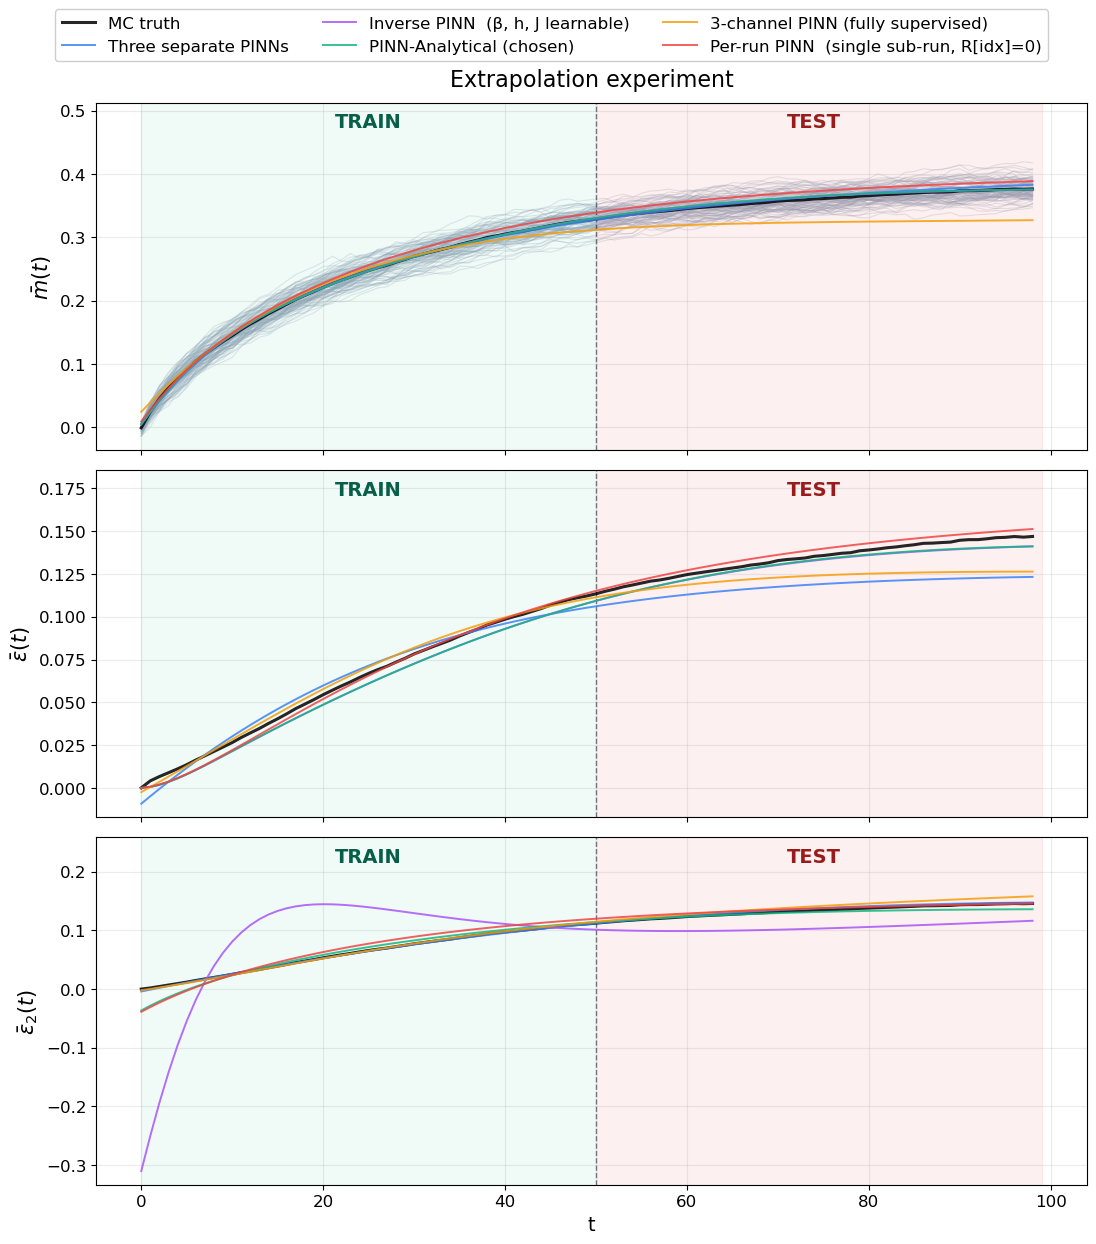

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(11, 13), sharex=True)
for ax_idx, (ax, (truth, key_obs, lbl)) in enumerate(zip(axes, [
    (m_bar, 'm_hat', r'$\bar m(t)$'),
    (eps_bar, 'eps_hat', r'$\bar\varepsilon(t)$'),
    (eps2_bar, 'eps2_hat', r'$\bar\varepsilon_2(t)$'),
])):
    ax.axvspan(0, T_TRAIN_MAX, alpha=0.06, color='#10b981')
    ax.axvspan(T_TRAIN_MAX, t_grid[-1] + 1.0,   alpha=0.08, color='#ef4444')
    ax.axvline(T_TRAIN_MAX, color='#1e293b', ls='-', lw=1, alpha=0.6)
    if ax_idx == 0 and 'm_per_run' in data:
        for run in data['m_per_run']:
            ax.plot(t_grid, run, color='#94a3b8', lw=0.8, alpha=0.25, zorder=0)
    ax.plot(t_grid, truth, 'k-', lw=2.2, alpha=0.85, label='MC truth')
    for key, r in results_x.items():
        ax.plot(t_grid, r[key_obs], color=colors[key], lw=1.4, alpha=0.85, label=r['name'])

    ymin, ymax = ax.get_ylim()
    pad = (ymax - ymin) * 0.15
    ax.set_ylim(ymin, ymax + pad)
    ytop = ymax + pad

    ax.text(T_TRAIN_MAX/2, ymax + pad*0.45, 'TRAIN', ha='center', fontsize=14,
            color='#065f46', fontweight='bold')
    ax.text((T_TRAIN_MAX + t_grid[-1])/2, ymax + pad*0.45, 'TEST', ha='center',
            fontsize=14, color='#991b1b', fontweight='bold')

    ax.set_ylabel(lbl, fontsize=15)
    ax.tick_params(axis='both', labelsize=12)
    ax.grid(alpha=0.25)

axes[-1].set_xlabel('t', fontsize=14)
axes[0].set_title('Extrapolation experiment', fontsize=16, pad=12)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.96),
           ncol=3, fontsize=12, frameon=True, framealpha=0.95)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

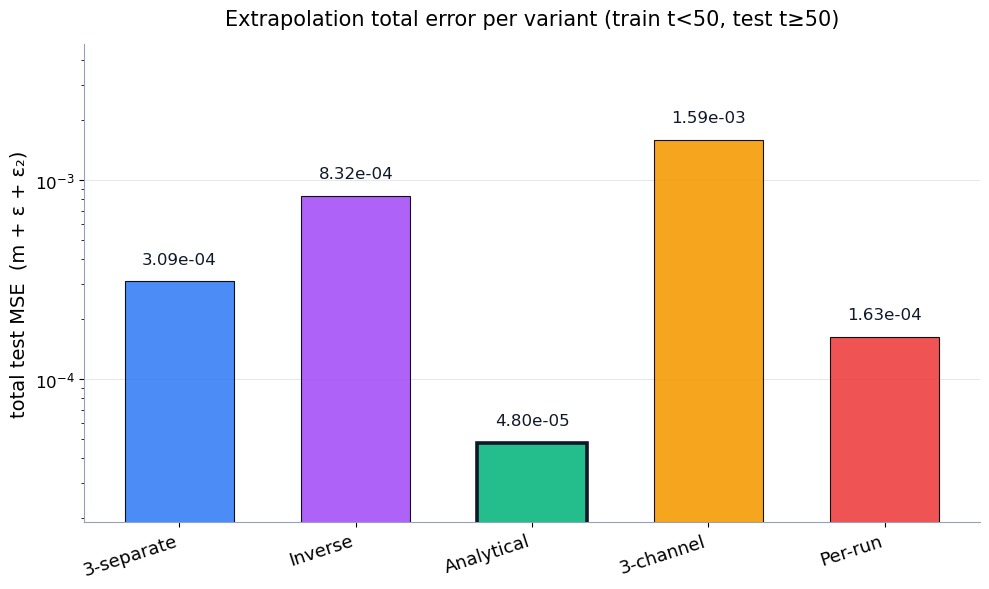

In [ ]:
variants_order = ['three_separate', 'inverse', 'analytical', 'three_channel', 'per_run']
short_names = {
    'three_separate': '3-separate',
    'inverse': 'Inverse',
    'analytical': 'Analytical',
    'three_channel': '3-channel',
    'per_run': 'Per-run',
}
bar_colors = {
    'three_separate': '#3b82f6',
    'inverse': '#a855f7',
    'analytical': '#10b981',
    'three_channel': '#f59e0b',
    'per_run': '#ef4444',
}

totals = [
    results_x[k]['mse_m_test'] + results_x[k]['mse_eps_test'] + results_x[k]['mse_eps2_test']
    for k in variants_order
]
names = [short_names[k] for k in variants_order]
cols  = [bar_colors[k]  for k in variants_order]
xs    = np.arange(len(variants_order))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(xs, totals, 0.62, color=cols, edgecolor='black',
              linewidth=0.8, alpha=0.92)

best_i = int(np.argmin(totals))
ax.bar(xs[best_i], totals[best_i], 0.62, color='none',
       edgecolor='#0f172a', linewidth=2.6, zorder=3)

for x, v in zip(xs, totals):
    ax.text(x, v * 1.18, f'{v:.2e}', ha='center', va='bottom',
            fontsize=12, color='#0f172a')

ax.set_xticks(xs)
ax.set_xticklabels(names, rotation=18, ha='right', fontsize=13)
ax.set_yscale('log')
ax.set_ylabel('total test MSE  (m + ε + ε₂)', fontsize=14)
ax.set_title('Extrapolation total error per variant '
             f'(train t<{T_TRAIN_MAX:.0f}, test t≥{T_TRAIN_MAX:.0f})',
             fontsize=15, pad=14)
ax.tick_params(axis='y', labelsize=12)

ymin = min(totals) / 2.5
ymax = max(totals) * 3.0
ax.set_ylim(ymin, ymax)

for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
ax.spines['left'].set_color('#94a3b8')
ax.spines['bottom'].set_color('#94a3b8')
ax.grid(True, axis='y', alpha=0.35, linewidth=0.6)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()